## Limit Testing

This jupyter notebook will demonstrate the robustness of the SIRT and FBP algorithm, specifically on pixel based phantoms. We will test it on limited angle ranges, limited number of projections, with/without noise, all with a parallel beam. 

In [ ]:
import matplotlib.pyplot as plt
from skimage import draw
import numpy as np
import os.path
import astra
astra.test() # if everything works properly you should see information about your GPU and CUDA capability

from os import mkdir

from ReconstructionAlgorithms import SIRT, FBP
from Sinograms import sinogram

if not os.path.exists("Pixel_phantoms_reconstructions"):
    mkdir("Pixel_phantoms_reconstructions")

# Basic settings for the sinogram creation and the reconstruction
ANGLES = np.linspace(0, np.pi, 180)
N_DETECTORS = 512
DETECTOR_SPACING = 1
I0 = None

PATH = "Geo_phantom\phantom_arrays\multiple_shapes_and_graylevels.npz" # Change this path if you want to test on a different phantom
PHANTOM = np.load(PATH)['arr_0']

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
C:\Users\coenb\AppData\Local\Temp\ipykernel_6052\3356361668.py:23: SyntaxWarning: invalid escape sequence '\p'
  PATH = "Geo_phantom\phantom_arrays\multiple_shapes_and_graylevels.npz" # Change this path if you want to test on a different phantom


No GPU support available
ASTRA Toolbox v2.4.1
Testing basic CPU 2D functionality... Ok


### Function for making figures

In [2]:

def plot(sirt_reconstructions, fbp_reconstructions, figsize=(10, 10)):
    fig_width = len(sirt_reconstructions)
    fig, ax = plt.subplots(nrows=2, ncols=fig_width, figsize=(5 * fig_width, 10))

    for i, reconstruction in enumerate(sirt_reconstructions):
        ax[0, i].imshow(reconstruction, cmap='gray')
        ax[0, i].axis('off')

    for i, reconstruction in enumerate(fbp_reconstructions):
        ax[1, i].imshow(reconstruction, cmap='gray')
        ax[1, i].axis('off')
        
    fig.tight_layout()

    plt.show()

## Limited Angle Problem

We will first test the robustness of the reconstruction algorithms for limited angle ranges; [180, 135, 90, 45]. All observations will be seperated by 1 degree. 

In [ ]:

#Different angles used
delta_angle = (45/2)/180 * np.pi 
angle_ranges = [
                np.linspace(0, np.pi, 180), 
                np.linspace(delta_angle, np.pi - delta_angle, 135),
                np.linspace(2*delta_angle, np.pi - 2*delta_angle, 90),
                np.linspace(3*delta_angle, np.pi - 3*delta_angle, 45)
                ]


sirt_reconstructions = []
fbp_reconstructions = []
for angle in angle_ranges:
    proj_id, sino_id, sinogram_img, volume_geom, projection_geom = sinogram(phantom=PHANTOM,
                                                                            n_detectors=N_DETECTORS,
                                                                            angles=angle,
                                                                            detector_spacing=DETECTOR_SPACING,
                                                                            intensity_scale=I0)
    _, sirt_reconstruction = SIRT(vol_geom=volume_geom,
                                proj_geom=projection_geom,
                                sinogram=sinogram_img,
                                projector_id=proj_id,
                                vol_data=0,
                                iters=200)
    sirt_reconstructions.append(sirt_reconstruction)

    _, fbp_reconstruction = FBP(vol_geom=volume_geom,
                                sino_id=sino_id,
                                proj_geom=projection_geom,
                                sinogram=sinogram_img)
    fbp_reconstructions.append(fbp_reconstruction)


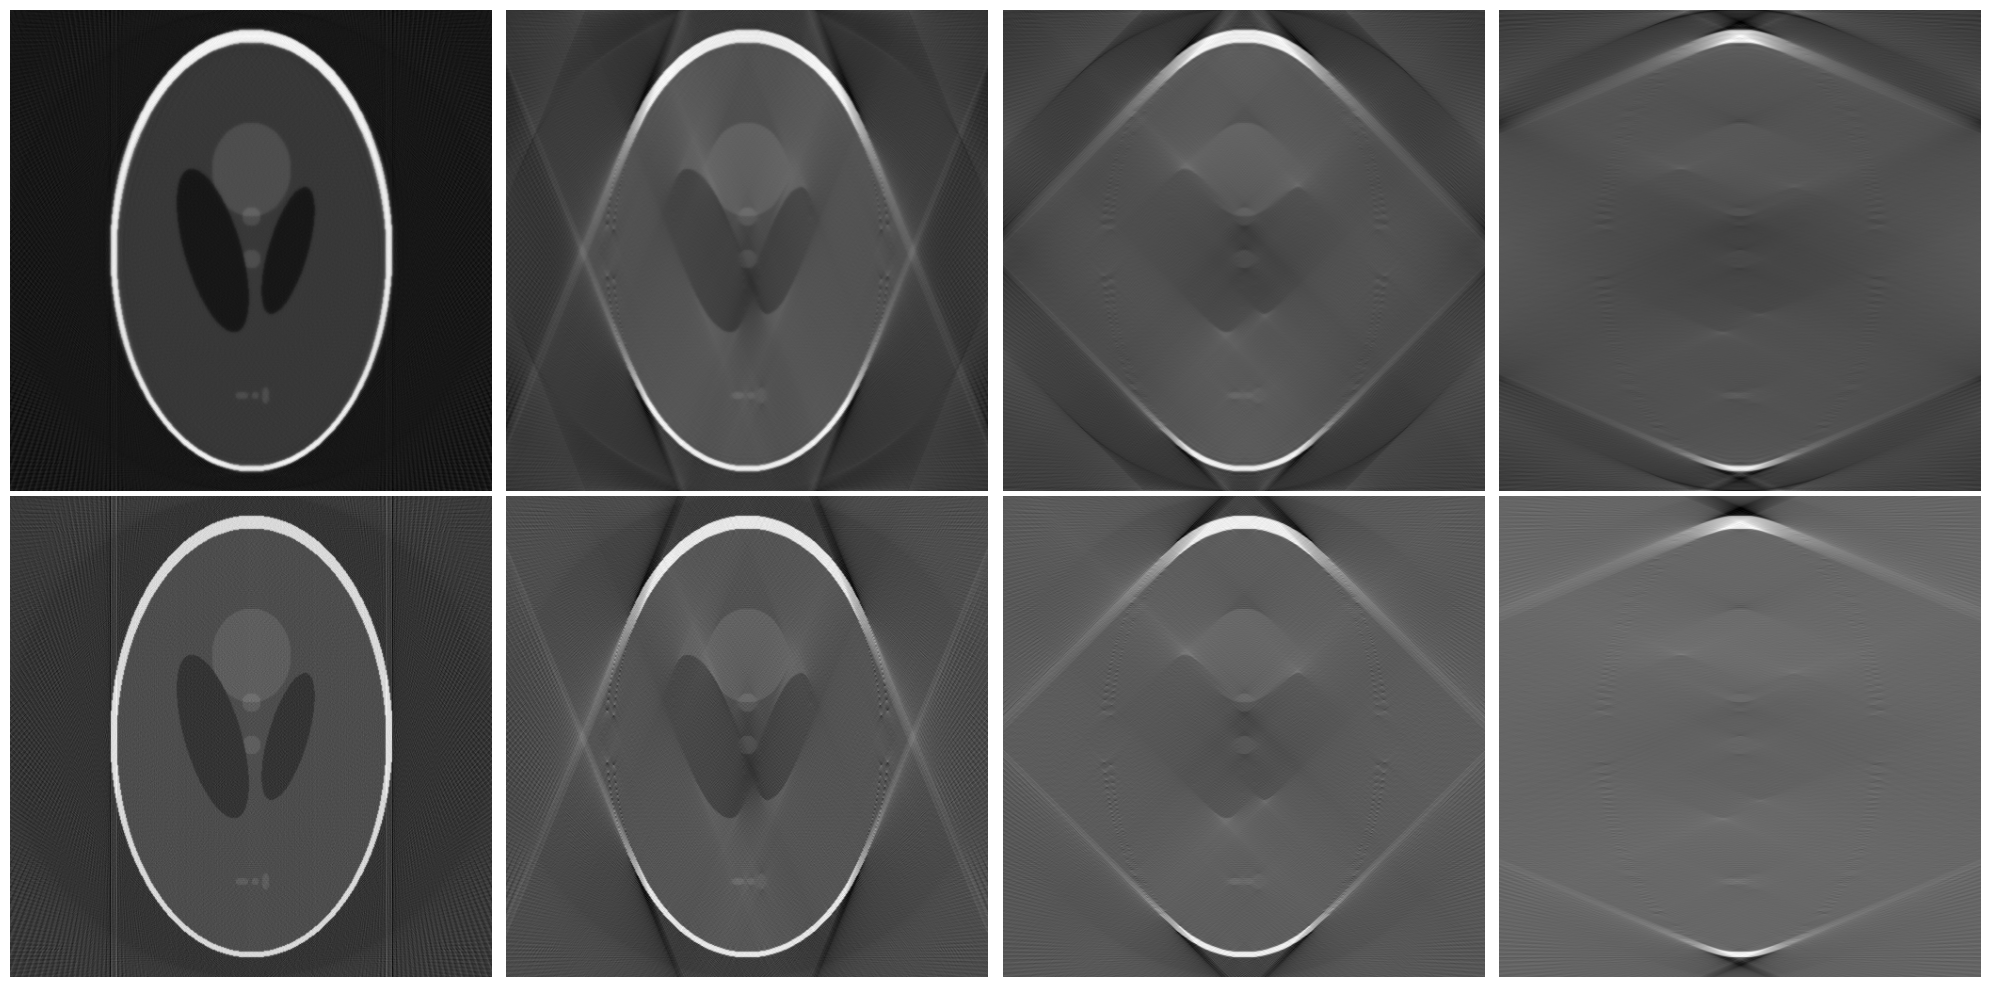

In [4]:
plot(sirt_reconstructions, fbp_reconstructions)

## Limited Number of Projections

To test the reconstruction algorithms further we will also test it with limited number of projections: [180, 120, 60, 30], over the entire range of [0, pi].

In [ ]:
# Different angle ranges to test the algorithms against
angle_ranges = [
                np.linspace(0, np.pi, 180), 
                np.linspace(0, np.pi, 120), 
                np.linspace(0, np.pi, 60), 
                np.linspace(0, np.pi, 30), 
                ]


sirt_reconstructions = []
fbp_reconstructions = []
for angle in angle_ranges:
    proj_id, sino_id, sinogram_img, volume_geom, projection_geom = sinogram(phantom=PHANTOM,
                                                                            n_detectors=N_DETECTORS,
                                                                            angles=angle,
                                                                            detector_spacing=DETECTOR_SPACING,
                                                                            intensity_scale=I0)
    _, sirt_reconstruction = SIRT(vol_geom=volume_geom,
                                proj_geom=projection_geom,
                                sinogram=sinogram_img,
                                projector_id=proj_id,
                                vol_data=0,
                                iters=200)
    sirt_reconstructions.append(sirt_reconstruction)

    _, fbp_reconstruction = FBP(vol_geom=volume_geom,
                                sino_id=sino_id,
                                proj_geom=projection_geom,
                                sinogram=sinogram_img)
    fbp_reconstructions.append(fbp_reconstruction)


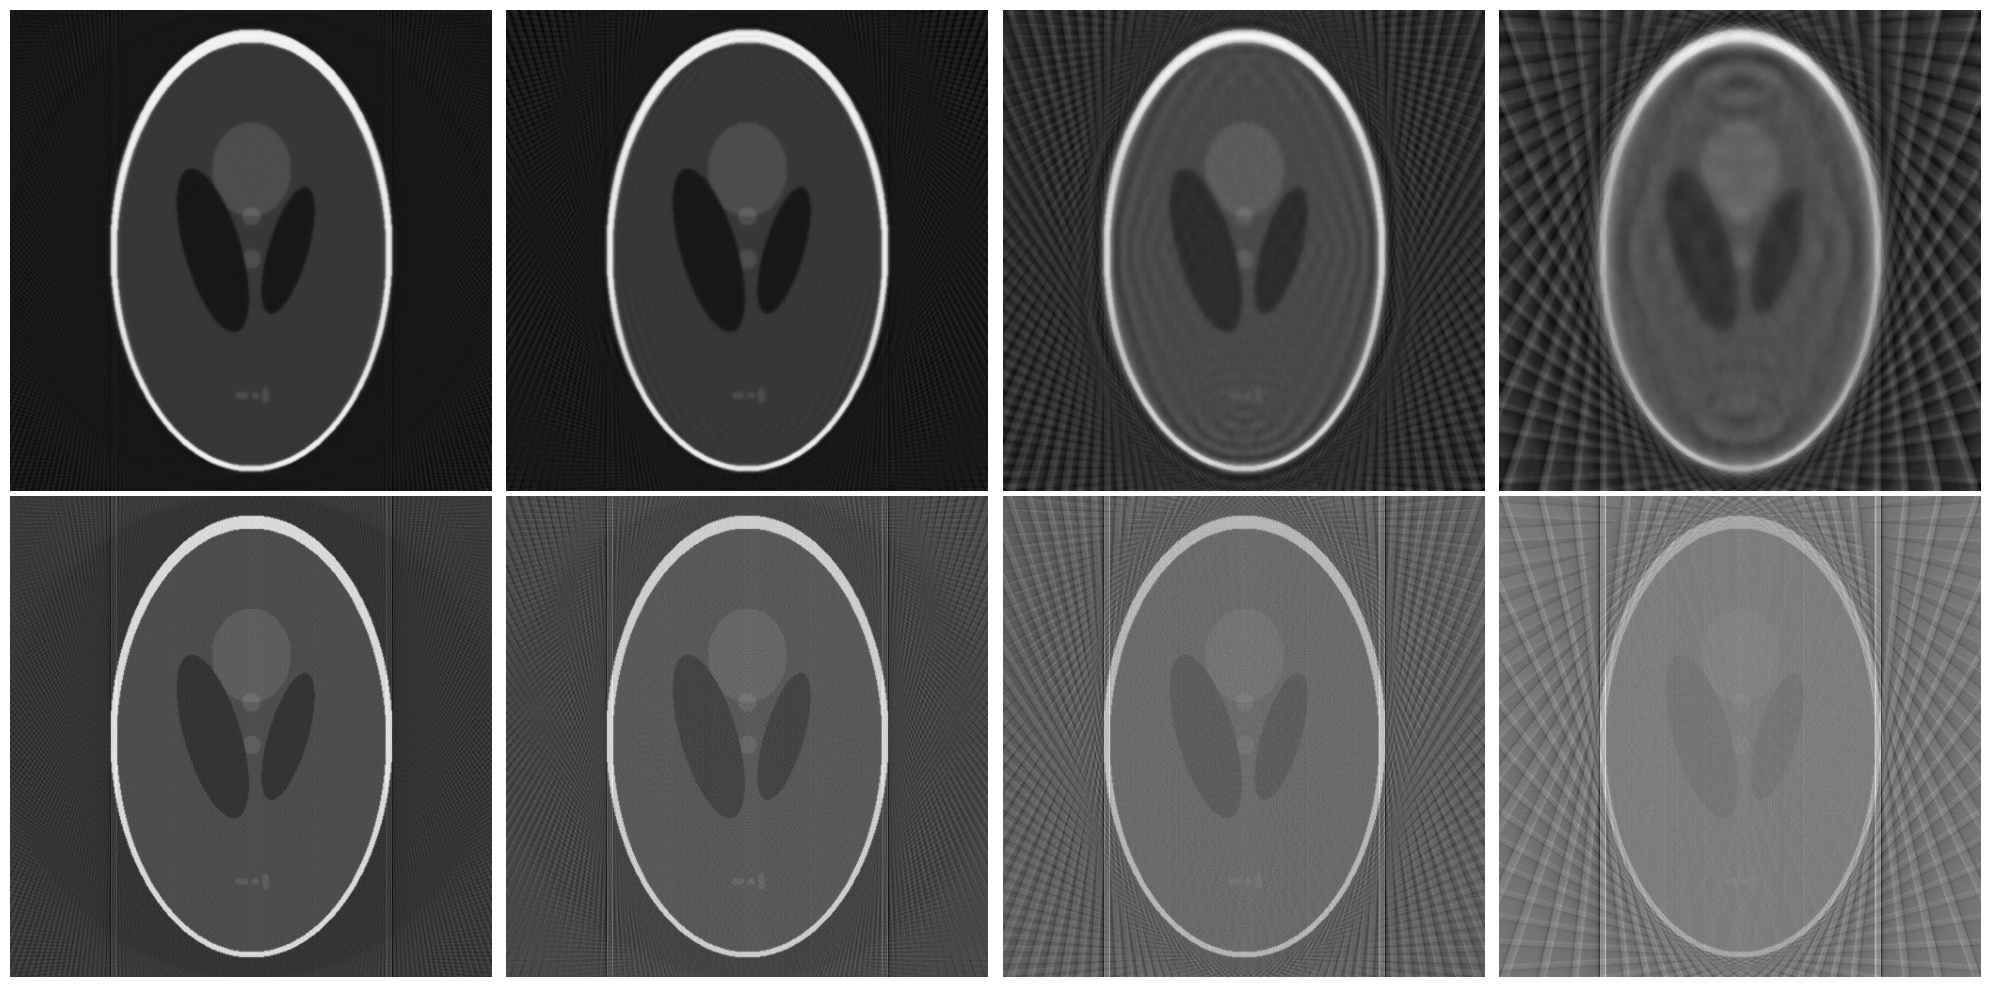

In [8]:
plot(sirt_reconstructions, fbp_reconstructions)

## Add Some Noise

The final test is to see how well the algorithms can handle different levels of noise. The noise is modelled using a poisson distribution and are defined by the number of photons that are injected into the sinogram as noise: [10^5, 10^4, 10^2]

In [ ]:
# Different initial intesities
initial_intensities = [10**5, 10**4, 10**2]


sirt_reconstructions = []
fbp_reconstructions = []
for intensity in initial_intensities:
    proj_id, sino_id, sinogram_img, volume_geom, projection_geom = sinogram(phantom=PHANTOM,
                                                                            n_detectors=N_DETECTORS,
                                                                            angles=ANGLES,
                                                                            detector_spacing=DETECTOR_SPACING,
                                                                            intensity_scale=intensity)
    _, sirt_reconstruction = SIRT(vol_geom=volume_geom,
                                proj_geom=projection_geom,
                                sinogram=sinogram_img,
                                projector_id=proj_id,
                                vol_data=0,
                                iters=200)
    sirt_reconstructions.append(sirt_reconstruction)

    _, fbp_reconstruction = FBP(vol_geom=volume_geom,
                                sino_id=sino_id,
                                proj_geom=projection_geom,
                                sinogram=sinogram_img)
    fbp_reconstructions.append(fbp_reconstruction)


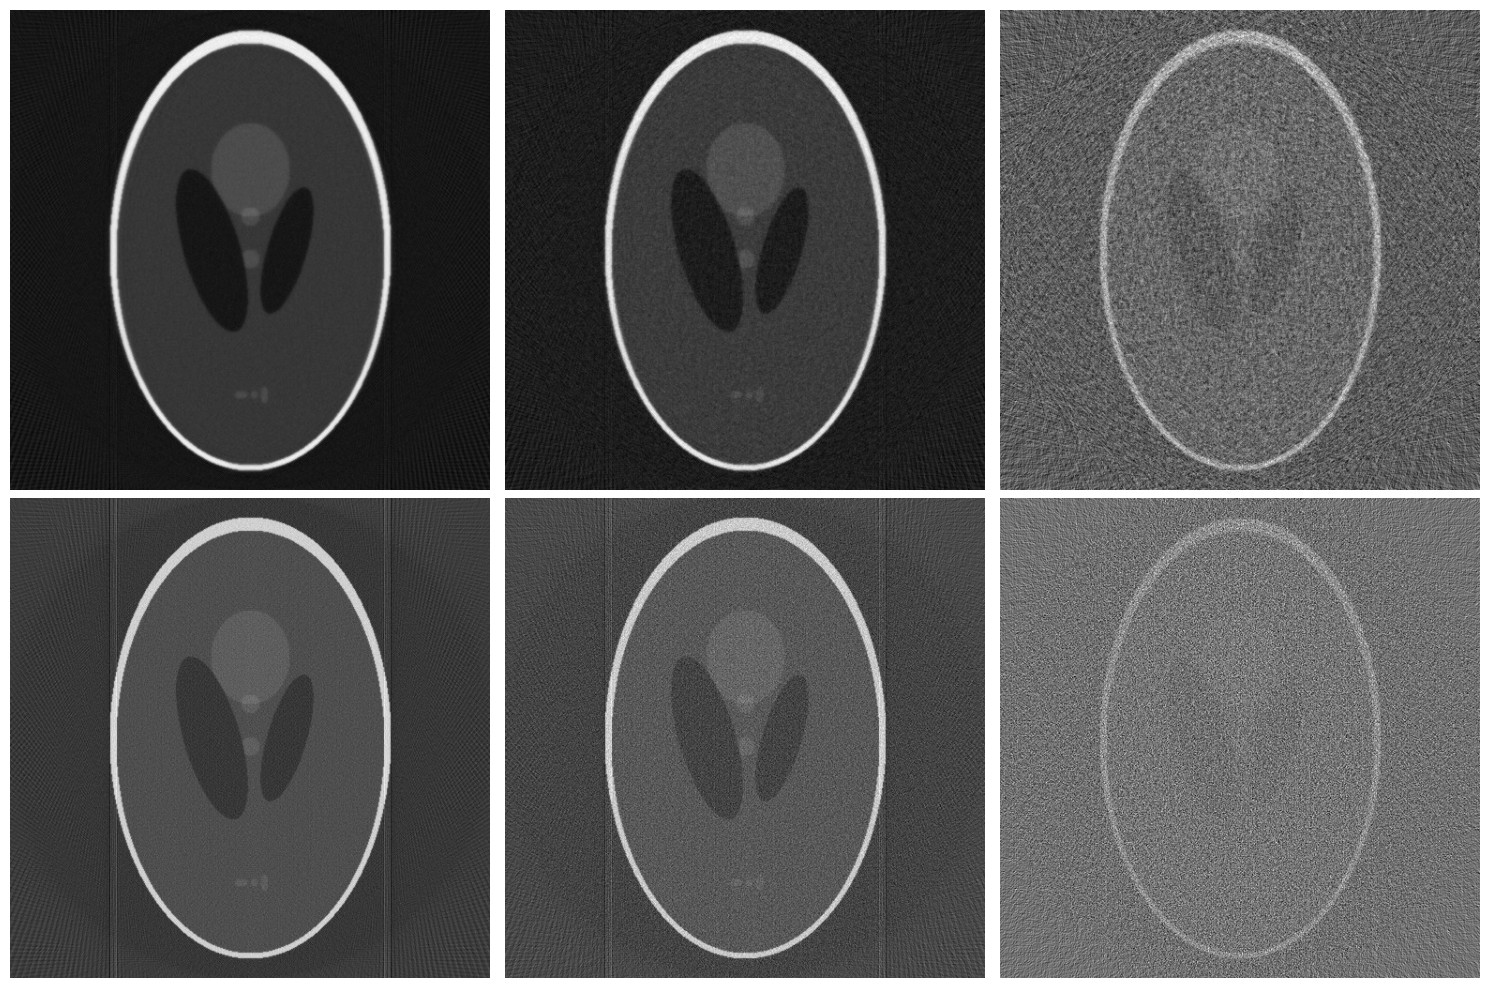

In [5]:
plot(sirt_reconstructions, fbp_reconstructions)